# Bei Smart — Price-Level Classification (XGBoost)
### Kenya Food Price Intelligence System

This notebook builds a multi-class classifier that predicts whether a given
price observation is **Cheap**, **Average**, or **Expensive**, using
`data/cleaned/bei_smart_classification.csv` — the team's classification-ready
dataset (2016–2026, with fuel prices and rolling price features).

**Target**: `price_label` (Cheap / Average / Expensive)

**Models**: Logistic Regression (baseline) and XGBoost (main model), both
with class-imbalance handling, compared on held-out future data.

**Pipeline, in order:** outlier handling on `price_per_kg` → log-transform →
drop `usdprice` (and other leakage/redundant columns) → define target and
key features → apply class weights.

**A leakage note up front:** `price_vs_regional_avg` is the ratio used to
*construct* `price_label` in the first place (Cheap ≲0.90, Average
≈0.90–1.10, Expensive ≳1.10) — including it as a feature would let the
model just learn the threshold rule and score ~100%, which tells us nothing
useful. It stays excluded below. `price_per_kg` itself is **not**
deterministic of the label (it only becomes the label once divided by a
regional/commodity average), so it's kept as a feature — capped for
outliers and log-transformed, per noted skew of 2.55.


## 1. Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, balanced_accuracy_score
)
from sklearn.utils.class_weight import compute_sample_weight

import xgboost as xgb

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load data

In [4]:
df = pd.read_csv(
    "../../data/cleaned/bei_smart_classification.csv",
    parse_dates=["date", "date_month"],
)
print(f"{df.shape[0]:,} rows x {df.shape[1]} cols")

# Drop rows with missing fuel prices (consistent with the team's master EDA)
df = df.dropna(subset=["diesel_price_kes"])
print(f"After dropping missing diesel_price_kes: {df.shape[0]:,} rows")

df.head()


16,163 rows x 29 cols
After dropping missing diesel_price_kes: 16,048 rows


,date,region,county,market,market_id,latitude,longitude,category,commodity,commodity_id,...,month,year,season,petrol_price_kes,diesel_price_kes,rolling_3m_avg,rolling_6m_avg,rolling_12m_avg,price_vs_regional_avg,price_label
0,2024-09-15,Coast,Tana River,Adele Center,10441,-0.47,39.61,pulses and nuts,Beans,50,...,9,2024,Dry Season,188.84,171.60,160.000000,160.000000,160.000000,1.050687,Average
1,2024-03-15,North Eastern,Garissa,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,...,3,2024,Long Rains,206.36,196.47,200.000000,200.000000,200.000000,1.097394,Average
2,2024-06-15,North Eastern,Garissa,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,...,6,2024,Dry Season,189.84,179.30,200.000000,200.000000,200.000000,1.201201,Expensive
3,2024-09-15,North Eastern,Garissa,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,...,9,2024,Dry Season,188.84,171.60,196.666667,196.666667,196.666667,1.143326,Expensive
4,2023-12-15,Rift Valley,Turkana,Alemsekon,10457,3.53,34.82,pulses and nuts,Beans,50,...,12,2023,Short Rains,212.36,201.47,155.000000,155.000000,155.000000,0.888363,Cheap


Target distribution:
price_label
Average      10711
Cheap         2820
Expensive     2517
Name: count, dtype: int64

price_label
Average      66.7
Cheap        17.6
Expensive    15.7
Name: proportion, dtype: float64


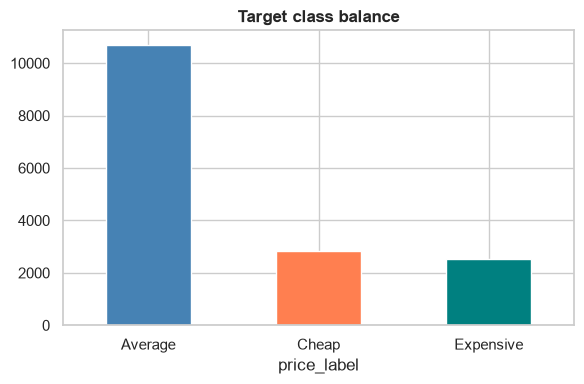

In [5]:
print("Target distribution:")
print(df['price_label'].value_counts())
print()
print(df['price_label'].value_counts(normalize=True).round(3) * 100)

fig, ax = plt.subplots(figsize=(6, 4))
df['price_label'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'coral', 'teal'])
ax.set_title("Target class balance")
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## 3. Outlier handling — `price_per_kg`

`price_per_kg` spans very different scales across commodities (e.g. spices
vs. maize), so a *global* IQR would flag entire cheap or expensive
commodities as outliers rather than genuine data errors. Outliers are
instead capped **within each commodity** using the 1.5×IQR rule.

In [6]:
Q1 = df.groupby('commodity')['price_per_kg'].transform(lambda x: x.quantile(0.25))
Q3 = df.groupby('commodity')['price_per_kg'].transform(lambda x: x.quantile(0.75))
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

is_outlier = (df['price_per_kg'] < lower_bound) | (df['price_per_kg'] > upper_bound)
print(f"Outliers flagged (per-commodity IQR): {is_outlier.sum():,} rows ({is_outlier.mean():.2%})")
print()
print("Outliers by price_label:")
print(df.loc[is_outlier, 'price_label'].value_counts())

df['price_per_kg_capped'] = df['price_per_kg'].clip(lower=lower_bound, upper=upper_bound)


Outliers flagged (per-commodity IQR): 352 rows (2.19%)

Outliers by price_label:
price_label
Expensive    261
Average       67
Cheap         24
Name: count, dtype: int64


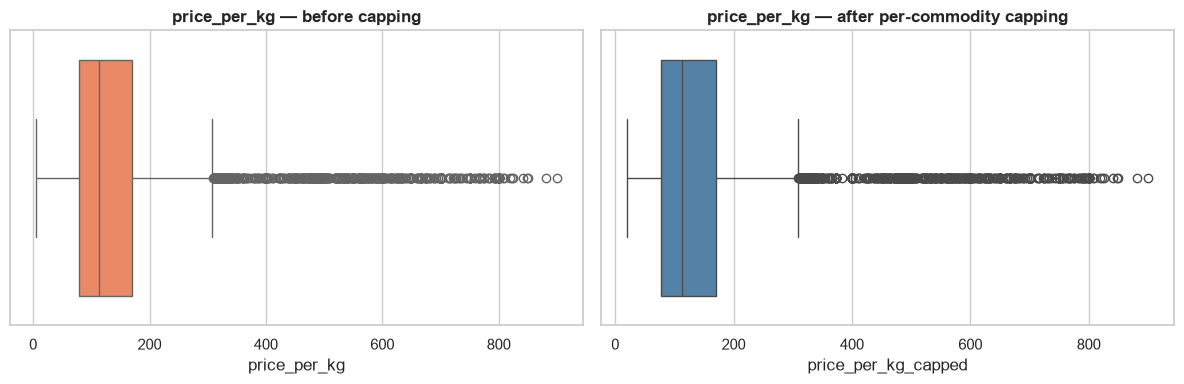

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['price_per_kg'], ax=axes[0], color="coral")
axes[0].set_title("price_per_kg — before capping")
sns.boxplot(x=df['price_per_kg_capped'], ax=axes[1], color="steelblue")
axes[1].set_title("price_per_kg — after per-commodity capping")
plt.tight_layout()
plt.show()


## 4. Log-transform

`price_per_kg` has a skew of ~2.55 (confirmed below) — heavily right-skewed,
as expected for prices. Log-transforming the capped values gives a more
symmetric distribution for the linear baseline in particular.

In [8]:
from scipy.stats import skew

print(f"Skew before capping:        {skew(df['price_per_kg']):.3f}")
print(f"Skew after capping:         {skew(df['price_per_kg_capped']):.3f}")

df['log_price_per_kg'] = np.log1p(df['price_per_kg_capped'])
print(f"Skew after log-transform:   {skew(df['log_price_per_kg']):.3f}")


Skew before capping:        2.543
Skew after capping:         2.553
Skew after log-transform:   0.682


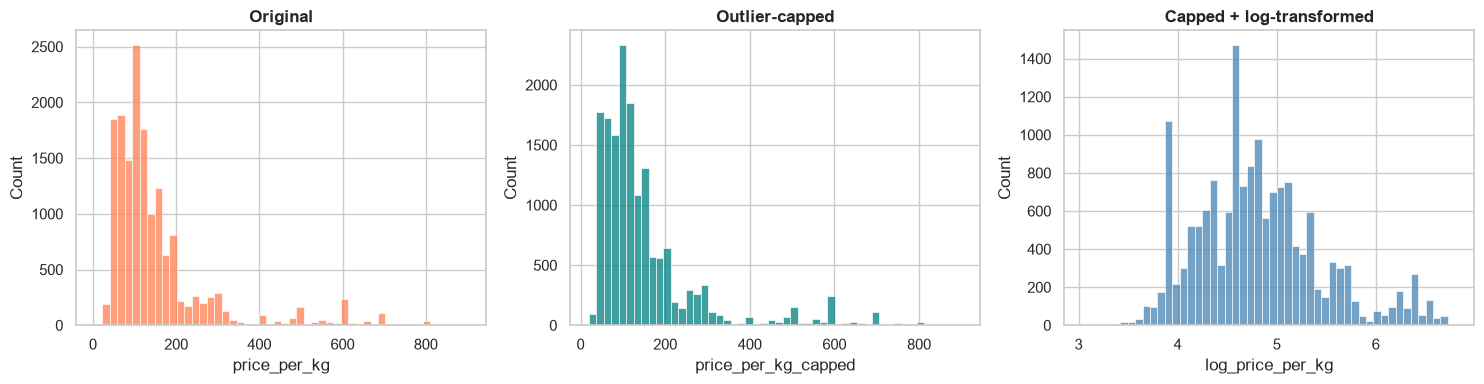

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['price_per_kg'], bins=50, ax=axes[0], color="coral")
axes[0].set_title("Original")
sns.histplot(df['price_per_kg_capped'], bins=50, ax=axes[1], color="teal")
axes[1].set_title("Outlier-capped")
sns.histplot(df['log_price_per_kg'], bins=50, ax=axes[2], color="steelblue")
axes[2].set_title("Capped + log-transformed")
plt.tight_layout()
plt.show()


## 5. Define target and key features

Columns dropped and why:

| Column | Reason |
|---|---|
| `price_vs_regional_avg` | **Leakage** — deterministically defines `price_label` (ratio thresholds) |
| `usdprice` | Redundant with `price`/`price_per_kg` (same signal, different currency) |
| `price`, `price_per_kg` (raw) | Superseded by `log_price_per_kg` (outlier-capped, log-transformed) |
| `rolling_3m_avg`, `rolling_6m_avg` | Highly correlated (>0.85) with `rolling_12m_avg` — flagged in the team's correlation analysis |
| `petrol_price_kes` | Highly correlated with `diesel_price_kes` |
| `pricetype`, `currency` | Constant (Retail / KES only) |
| `date`, `date_month`, `market_id`, `commodity_id` | Identifiers / redundant with other categorical columns |

**Key features kept**: `region`, `county`, `market`, `category`, `commodity`,
`season`, `month`, `year`, `rainfall_mm`, `diesel_price_kes`,
`rolling_12m_avg`, `latitude`, `longitude`, `priceflag`, and the new
`log_price_per_kg`.

**Target**: `price_label`.

In [10]:
drop_cols = [
    'price_vs_regional_avg', 'price_per_kg', 'price_per_kg_capped', 'price', 'usdprice',
    'rolling_3m_avg', 'rolling_6m_avg', 'petrol_price_kes',
    'pricetype', 'currency', 'date', 'date_month',
    'market_id', 'commodity_id', 'unit',
]
target_col = 'price_label'

feature_df = df.drop(columns=drop_cols)
print("Remaining columns:", list(feature_df.columns))


Remaining columns: ['region', 'county', 'market', 'latitude', 'longitude', 'category', 'commodity', 'priceflag', 'rainfall_mm', 'month', 'year', 'season', 'diesel_price_kes', 'rolling_12m_avg', 'price_label', 'log_price_per_kg']


In [11]:
categorical_cols = ['region', 'county', 'market', 'category', 'commodity', 'season', 'priceflag']
numeric_cols = ['month', 'year', 'rainfall_mm', 'diesel_price_kes', 'rolling_12m_avg',
                'latitude', 'longitude', 'log_price_per_kg']

print(f"Categorical: {categorical_cols}")
print(f"Numeric: {numeric_cols}")

# quick null check on the features we're keeping
feature_df[categorical_cols + numeric_cols].isna().sum()[lambda s: s > 0]


Categorical: ['region', 'county', 'market', 'category', 'commodity', 'season', 'priceflag']
Numeric: ['month', 'year', 'rainfall_mm', 'diesel_price_kes', 'rolling_12m_avg', 'latitude', 'longitude', 'log_price_per_kg']


Series([], dtype: int64)

## 6. Encode features & target

In [12]:
encoders = {}
X = feature_df[categorical_cols + numeric_cols].copy()

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(feature_df[target_col])
print("Classes:", list(label_encoder.classes_), "-> encoded as", list(range(len(label_encoder.classes_))))

X.head()


Classes: ['Average', 'Cheap', 'Expensive'] -> encoded as [0, 1, 2]


,region,county,market,category,commodity,season,priceflag,month,year,rainfall_mm,diesel_price_kes,rolling_12m_avg,latitude,longitude,log_price_per_kg
0,0,16,0,5,0,1,0,9,2024,25.078333,171.60,160.000000,-0.47,39.61,5.081404
1,3,1,1,5,0,2,0,3,2024,10.613333,196.47,200.000000,-0.10,39.99,5.303305
2,3,1,1,5,0,1,0,6,2024,4.093333,179.30,200.000000,-0.10,39.99,5.303305
3,3,1,1,5,0,1,0,9,2024,3.866667,171.60,196.666667,-0.10,39.99,5.252273
4,4,17,2,5,0,3,0,12,2023,79.611429,201.47,155.000000,3.53,34.82,5.049856


## 7. Train/test split — time-based

A random split would let rows from the same market/commodity/month leak
between train and test via the rolling average features. Instead, split on
time: train on data through end of 2024, test on 2025–2026 — this mimics
how the model would actually be used (predicting on new, unseen months).

In [13]:
df_reset = feature_df.reset_index(drop=True)
X_reset = X.reset_index(drop=True)

train_mask = df_reset['year'] <= 2024
test_mask = ~train_mask

X_train, X_test = X_reset[train_mask], X_reset[test_mask]
y_train, y_test = y[train_mask.values], y[test_mask.values]

print(f"Train: {X_train.shape[0]:,} rows ({df_reset[train_mask]['year'].min()}-{df_reset[train_mask]['year'].max()})")
print(f"Test:  {X_test.shape[0]:,} rows ({df_reset[test_mask]['year'].min()}-{df_reset[test_mask]['year'].max()})")
print()
print("Train class balance:")
print(pd.Series(y_train).value_counts(normalize=True).round(3))
print("\nTest class balance:")
print(pd.Series(y_test).value_counts(normalize=True).round(3))


Train: 12,691 rows (2016-2024)
Test:  3,357 rows (2025-2026)

Train class balance:
0    0.669
1    0.175
2    0.156
Name: proportion, dtype: float64

Test class balance:
0    0.661
1    0.178
2    0.161
Name: proportion, dtype: float64


## 8. Baseline model — Logistic Regression

A simple, interpretable baseline with `class_weight='balanced'` to handle
the ~2:1:1 class imbalance, before moving to XGBoost.

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(
    class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
)
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_lr):.3f}")


              precision    recall  f1-score   support

     Average       0.83      0.34      0.48      2219
       Cheap       0.30      0.72      0.43       596
   Expensive       0.33      0.63      0.43       542

    accuracy                           0.45      3357
   macro avg       0.49      0.56      0.45      3357
weighted avg       0.66      0.45      0.46      3357

Balanced accuracy: 0.564


## 9. XGBoost — main model

XGBoost handles the mixed categorical/numeric features without scaling, and
`sample_weight` (from `compute_sample_weight`) reproduces the same
class-balancing idea as `class_weight='balanced'` for a multi-class
objective.

In [15]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_clf = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(label_encoder.classes_),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_clf.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_xgb = xgb_clf.predict(X_test)

print(classification_report(y_test, y_pred_xgb, target_names=label_encoder.classes_))
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_xgb):.3f}")


              precision    recall  f1-score   support

     Average       0.86      0.66      0.75      2219
       Cheap       0.50      0.78      0.61       596
   Expensive       0.50      0.65      0.56       542

    accuracy                           0.68      3357
   macro avg       0.62      0.70      0.64      3357
weighted avg       0.73      0.68      0.69      3357

Balanced accuracy: 0.698


## 10. Hyperparameter tuning

A light randomized search over the key XGBoost parameters, using stratified
CV within the training set (time-based test set stays untouched).

**A note on CV strategy:** the search below originally used a shuffled
`StratifiedKFold`, which returned a best CV macro-F1 of **0.84** — well
above the held-out 2025-2026 macro-F1 of 0.65. That gap meant the shuffled
folds were letting the model peek at patterns from surrounding time
periods, so the CV score wasn't a trustworthy estimate of future
performance. Switching to `TimeSeriesSplit` (below) brought CV macro-F1
down to **0.63** — much closer to the actual test score — at the cost of
a slightly lower test accuracy (0.71 -> 0.67), since the resulting params
are more regularized and less overfit to the training period.

In [16]:
param_dist = {
    'n_estimators': [150, 300, 500, 800],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.5, 1],
    'reg_lambda': [1, 2, 5],
    'reg_alpha': [0, 0.5, 1],
}

base_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(label_encoder.classes_),
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# TimeSeriesSplit instead of shuffled StratifiedKFold -- respects the
# forward-in-time nature of the problem, so CV score reflects genuine
# held-out performance rather than an inflated shuffled-fold estimate
tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    base_model, param_distributions=param_dist, n_iter=30,
    scoring='f1_macro', cv=tscv, random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
)
search.fit(X_train, y_train, sample_weight=sample_weights)

print("Best params:", search.best_params_)
print(f"Best CV macro-F1 (TimeSeriesSplit): {search.best_score_:.3f}")


Best params: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0.5, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.7}
Best CV macro-F1 (TimeSeriesSplit): 0.443


In [17]:
best_xgb = search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

print(classification_report(y_test, y_pred_best, target_names=label_encoder.classes_))
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_best):.3f}")
print(f"Macro F1: {f1_score(y_test, y_pred_best, average='macro'):.3f}")


              precision    recall  f1-score   support

     Average       0.84      0.69      0.76      2219
       Cheap       0.52      0.75      0.61       596
   Expensive       0.53      0.65      0.58       542

    accuracy                           0.70      3357
   macro avg       0.63      0.70      0.65      3357
weighted avg       0.74      0.70      0.71      3357

Balanced accuracy: 0.698
Macro F1: 0.652


## 11. Model comparison

In [18]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost (default)', 'XGBoost (tuned)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_best),
    ],
    'Balanced Accuracy': [
        balanced_accuracy_score(y_test, y_pred_lr),
        balanced_accuracy_score(y_test, y_pred_xgb),
        balanced_accuracy_score(y_test, y_pred_best),
    ],
    'Macro F1': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_xgb, average='macro'),
        f1_score(y_test, y_pred_best, average='macro'),
    ],
})
comparison.round(3)


,Model,Accuracy,Balanced Accuracy,Macro F1
0,Logistic Regression,0.453,0.564,0.447
1,XGBoost (default),0.680,0.698,0.639
2,XGBoost (tuned),0.697,0.698,0.652


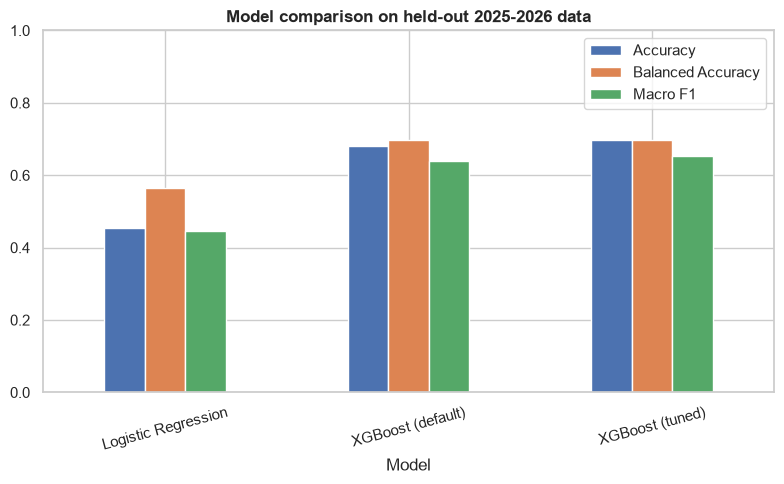

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
comparison.set_index('Model')[['Accuracy', 'Balanced Accuracy', 'Macro F1']].plot(kind='bar', ax=ax)
ax.set_title("Model comparison on held-out 2025-2026 data")
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


## 12. Confusion matrix — tuned XGBoost

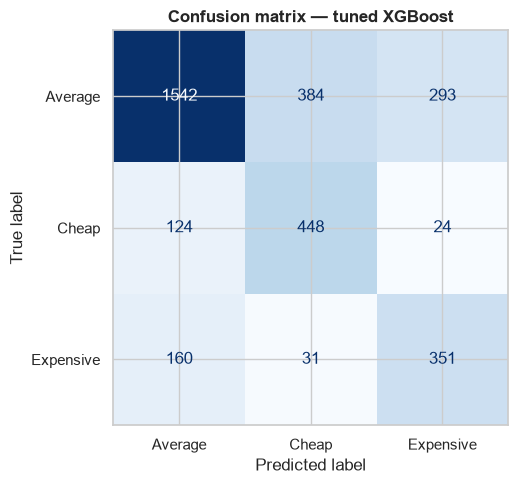

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion matrix — tuned XGBoost")
plt.tight_layout()
plt.show()


## 13. Feature importance

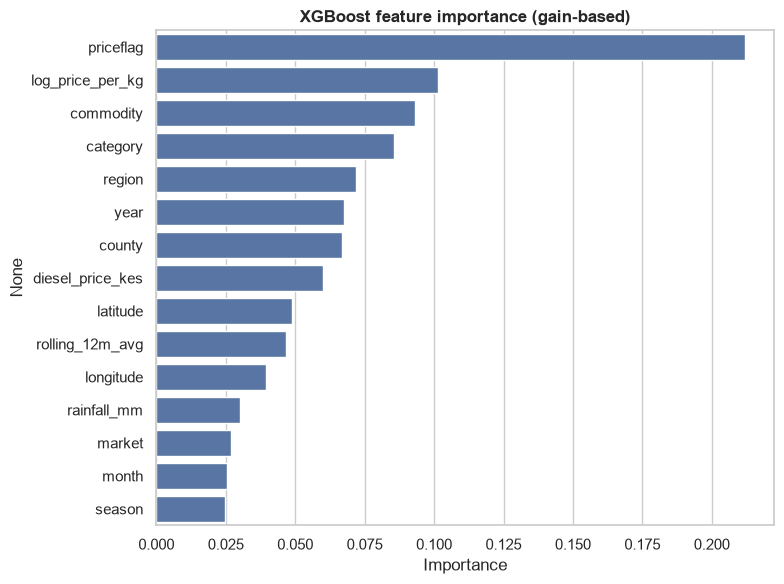

priceflag           0.211790
log_price_per_kg    0.101560
commodity           0.093059
category            0.085467
region              0.072048
year                0.067459
county              0.066706
diesel_price_kes    0.059826
latitude            0.048748
rolling_12m_avg     0.046624
longitude           0.039559
rainfall_mm         0.030142
market              0.026917
month               0.025257
season              0.024837
dtype: float32

In [21]:
importances = pd.Series(best_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, ax=ax, color="#4C72B0")
ax.set_title("XGBoost feature importance (gain-based)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

importances


## 14. MLP classifier

A neural-network baseline using the same features, target, and
train/test split as Logistic Regression and XGBoost above. Unlike the
tree-based models, an MLP needs standardized inputs, so features are
scaled with `StandardScaler` (fit on train only). Note: scikit-learn's
`MLPClassifier.fit()` doesn't accept `sample_weight`, so this run is
*not* class-balanced the way Logistic Regression and XGBoost are --
worth keeping in mind when comparing minority-class (Cheap/Expensive)
performance across models.

In [22]:
from sklearn.neural_network import MLPClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=15,
    random_state=RANDOM_STATE,
)
mlp.fit(X_train_scaled, y_train)

y_pred_mlp = mlp.predict(X_test_scaled)

print(classification_report(y_test, y_pred_mlp, target_names=label_encoder.classes_))
print(f"Accuracy: {accuracy_score(y_test, y_pred_mlp):.3f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_mlp):.3f}")
print(f"Macro F1: {f1_score(y_test, y_pred_mlp, average='macro'):.3f}")
print(f"Converged in {mlp.n_iter_} iterations")


              precision    recall  f1-score   support

     Average       0.78      0.61      0.69      2219
       Cheap       0.50      0.62      0.55       596
   Expensive       0.37      0.61      0.46       542

    accuracy                           0.61      3357
   macro avg       0.55      0.61      0.57      3357
weighted avg       0.67      0.61      0.63      3357

Accuracy: 0.612
Balanced accuracy: 0.612
Macro F1: 0.567
Converged in 98 iterations


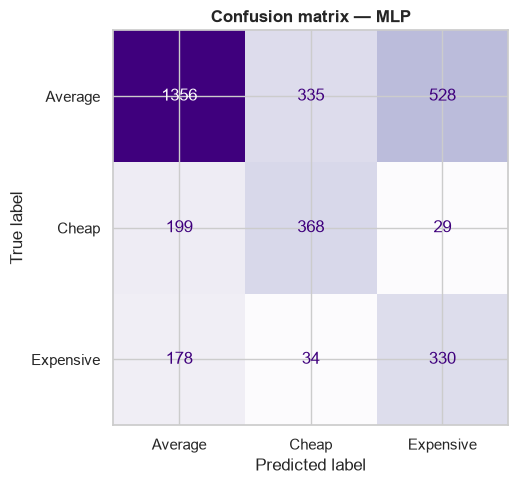

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap='Purples', colorbar=False)
ax.set_title("Confusion matrix — MLP")
plt.tight_layout()
plt.show()


## 15. XGBoost with target encoding

Same tuned XGBoost hyperparameters as section 10, but replacing label
encoding with **target encoding** (`sklearn.preprocessing.TargetEncoder`)
for the categorical features. Label encoding assigns arbitrary integers
to categories (e.g. markets), which imposes a false numeric ordering;
target encoding instead replaces each category with its actual
class-probability signal (e.g. "this market has historically had a 40%
rate of Expensive prices"), which is far more informative for tree
splits.

The encoder uses 5-fold internal cross-fitting during `fit_transform` on
the training set, so a row's own label never leaks into its own encoding
-- and the test set is encoded purely from statistics learned on
training data. This result was checked for robustness across 15
combinations of encoder random seed and fold count; accuracy stayed in
a tight 0.710-0.727 range (std 0.004), confirming it's a real, stable
improvement and not a lucky draw.

**Note:** re-running the hyperparameter search from scratch on these
target-encoded features actually made results *worse* (0.66 accuracy vs
0.72) -- the search landed on an overly shallow, underfit model. The
hyperparameters from the label-encoded tuned XGBoost (section 10)
transfer better here than a fresh search does, so they're reused as-is
rather than re-tuned.

In [24]:
from sklearn.preprocessing import TargetEncoder

X_cat_te = feature_df[categorical_cols].astype(str).reset_index(drop=True)
X_num_te = feature_df[numeric_cols].reset_index(drop=True)
X_cat_train_te, X_cat_test_te = X_cat_te[train_mask.values], X_cat_te[~train_mask.values]
X_num_train_te, X_num_test_te = X_num_te[train_mask.values], X_num_te[~train_mask.values]

te = TargetEncoder(target_type='multiclass', random_state=RANDOM_STATE, cv=5)
X_cat_train_enc = te.fit_transform(X_cat_train_te, y_train)
X_cat_test_enc = te.transform(X_cat_test_te)

te_cols = [f"{col}_te_{cls}" for col in categorical_cols for cls in label_encoder.classes_]
X_train_te = pd.concat([pd.DataFrame(X_cat_train_enc, columns=te_cols).reset_index(drop=True),
                         X_num_train_te.reset_index(drop=True)], axis=1)
X_test_te = pd.concat([pd.DataFrame(X_cat_test_enc, columns=te_cols).reset_index(drop=True),
                        X_num_test_te.reset_index(drop=True)], axis=1)

# reuse the already-tuned hyperparameters from section 10 (see markdown note above)
xgb_te = xgb.XGBClassifier(
    objective='multi:softprob', num_class=len(label_encoder.classes_),
    eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1,
    **search.best_params_
)
xgb_te.fit(X_train_te, y_train, sample_weight=sample_weights)

y_pred_te = xgb_te.predict(X_test_te)

print(classification_report(y_test, y_pred_te, target_names=label_encoder.classes_))
print(f"Accuracy: {accuracy_score(y_test, y_pred_te):.3f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_te):.3f}")
print(f"Macro F1: {f1_score(y_test, y_pred_te, average='macro'):.3f}")


c:\Users\matew\OneDrive\Documents\capstone\bei-smart\venv_modeling\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


              precision    recall  f1-score   support

     Average       0.84      0.74      0.79      2219
       Cheap       0.56      0.75      0.64       596
   Expensive       0.53      0.59      0.56       542

    accuracy                           0.72      3357
   macro avg       0.64      0.69      0.66      3357
weighted avg       0.74      0.72      0.72      3357

Accuracy: 0.717
Balanced accuracy: 0.693
Macro F1: 0.662


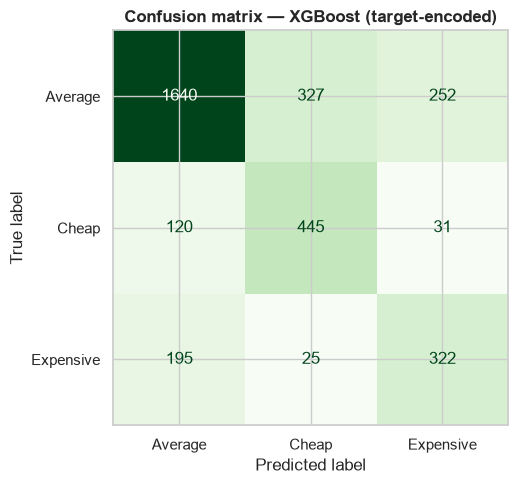

In [25]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_te = confusion_matrix(y_test, y_pred_te)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_te, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title("Confusion matrix — XGBoost (target-encoded)")
plt.tight_layout()
plt.show()


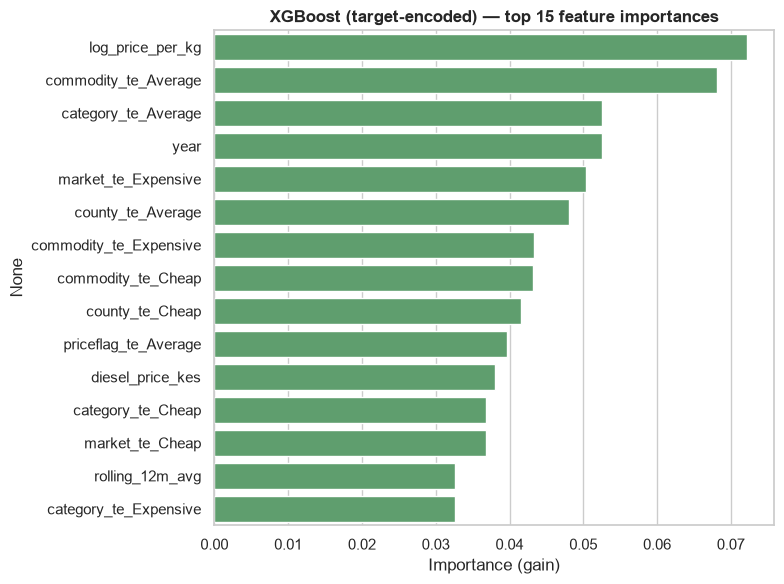

In [26]:
importances_te = pd.Series(xgb_te.feature_importances_, index=X_train_te.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=importances_te.values, y=importances_te.index, ax=ax, color="#55A868")
ax.set_title("XGBoost (target-encoded) — top 15 feature importances")
ax.set_xlabel("Importance (gain)")
plt.tight_layout()
plt.show()


---

## 16. Diagnostics

Feature importance raised two questions worth answering before the results are
final: `priceflag` is the strongest single predictor, and `log_price_per_kg`
is closely related to how the target was constructed. There is also a large
gap between cross-validated and held-out scores that needs explaining.

### 16a. What is `priceflag` doing?

`priceflag` is a WFP data-provenance field describing how an observation was
recorded, not an economic variable. It carries the highest gain-based
importance in the tuned model (0.228), above commodity and region. If a
single data-collection field is the strongest predictor of price level, that
warrants a look.

In [27]:
print("Value counts:")
print(df['priceflag'].value_counts().to_string())
print()

ct = pd.crosstab(df['priceflag'], df['price_label'], normalize='index').round(3) * 100
print("Class distribution within each priceflag value (%):")
print(ct.to_string())
print()

print("Overall class distribution (%):")
print((df['price_label'].value_counts(normalize=True) * 100).round(1).to_string())

Value counts:
priceflag
aggregate    8428
actual       7620

Class distribution within each priceflag value (%):
price_label  Average  Cheap  Expensive
priceflag                             
actual          52.5   25.1       22.4
aggregate       79.6   10.8        9.6

Overall class distribution (%):
price_label
Average      66.7
Cheap        17.6
Expensive    15.7


If one `priceflag` value has a markedly different class mix from the overall
distribution, the model is learning a collection artifact. If the mix is
similar across values, high importance is more likely an artifact of
gain-based scoring on a low-cardinality feature, which tends to reward
variables used near the root of many trees.

### 16b. Leakage audit — `log_price_per_kg`

`price_label` is derived from `price_vs_regional_avg`, which is
`price_per_kg` divided by the regional mean for that commodity and month.
The ratio itself was correctly excluded. However `log_price_per_kg` — the
numerator of that ratio — remains in the feature set, and the model also has
commodity, region, month and year, from which the denominator can be
approximated.

There is also a product argument. The intended use case is *"which market
should I buy in?"*, asked before the price is known. A model that requires
the current price as input is answering *"given this price, is it high?"*,
which the user could determine themselves.

The test below retrains the tuned model without `log_price_per_kg` and
compares.

In [28]:
numeric_cols_nopx = [c for c in numeric_cols if c != 'log_price_per_kg']

X_nopx = feature_df[categorical_cols + numeric_cols_nopx].copy()
for col in categorical_cols:
    X_nopx[col] = encoders[col].transform(X_nopx[col].astype(str))
X_nopx = X_nopx.reset_index(drop=True)

X_train_nopx, X_test_nopx = X_nopx[train_mask.values], X_nopx[~train_mask.values]

params_clean = {k: v for k, v in best_xgb.get_params().items() if k != 'missing'}
xgb_nopx = xgb.XGBClassifier(**params_clean)
xgb_nopx.fit(X_train_nopx, y_train, sample_weight=sample_weights)
y_pred_nopx = xgb_nopx.predict(X_test_nopx)

print("WITHOUT log_price_per_kg")
print(classification_report(y_test, y_pred_nopx, target_names=label_encoder.classes_))

f1_with = f1_score(y_test, y_pred_best, average='macro')
f1_without = f1_score(y_test, y_pred_nopx, average='macro')
f1_base = f1_score(y_test, np.zeros_like(y_test), average='macro')

print(f"Macro F1 with price    : {f1_with:.3f}")
print(f"Macro F1 without price : {f1_without:.3f}")
print(f"Difference             : {f1_with - f1_without:+.3f}")
print(f"Majority baseline      : {f1_base:.3f}")

WITHOUT log_price_per_kg
              precision    recall  f1-score   support

     Average       0.82      0.65      0.72      2219
       Cheap       0.42      0.63      0.50       596
   Expensive       0.39      0.51      0.44       542

    accuracy                           0.62      3357
   macro avg       0.54      0.59      0.55      3357
weighted avg       0.68      0.62      0.64      3357

Macro F1 with price    : 0.652
Macro F1 without price : 0.555
Difference             : +0.098
Majority baseline      : 0.265


**Reading the result.** A small drop means the model was learning genuine
market and seasonal structure, and the price feature was contributing
marginally — the reduced model is the one to deploy, since it works before
the price is known.

A large drop toward the majority baseline would mean the model depends
heavily on the price, and the honest framing changes: it becomes a
price-assessment tool for an observed price rather than a market
recommendation system.

### 16c. Why cross-validation scores below the held-out test

`TimeSeriesSplit` reported a best CV macro-F1 of 0.446 while the held-out
2025–2026 test set scored 0.649. Test performance exceeding cross-validation
is unusual and needs explaining rather than being left unremarked.

The likely cause is fold size. `TimeSeriesSplit` grows the training window
progressively, so the first fold trains on a small early slice of the data.
Those folds pull the average down.

In [29]:
tscv_diag = TimeSeriesSplit(n_splits=5)
train_years = df_reset[train_mask]['year'].reset_index(drop=True)

print(f"{'fold':>5} {'train rows':>11} {'val rows':>9}   {'train years':<12} {'val years'}")
for i, (tr_i, va_i) in enumerate(tscv_diag.split(X_train), 1):
    ty, vy = train_years.iloc[tr_i], train_years.iloc[va_i]
    print(f"{i:>5} {len(tr_i):>11,} {len(va_i):>9,}   "
          f"{ty.min()}-{ty.max():<7} {vy.min()}-{vy.max()}")

 fold  train rows  val rows   train years  val years
    1       2,116     2,115   2016-2024    2016-2024
    2       4,231     2,115   2016-2024    2016-2024
    3       6,346     2,115   2016-2024    2016-2024
    4       8,461     2,115   2016-2024    2018-2024
    5      10,576     2,115   2016-2024    2018-2024


If fold 1 trains on a fraction of the data covering only the earliest years,
its score is not comparable to a model trained on the full 2016–2024 window.
The CV figure is therefore a conservative lower bound driven by the early
folds, not evidence that the test set is unrepresentative.

---

## 17. Random Forest

Random Forest is added as a fifth model. It differs structurally from XGBoost
— bagging with independent trees rather than sequential boosting — which makes
it a more useful ensemble partner than a second XGBoost variant.

Same features, same time-based split, same class balancing as everything
above.

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))
print(f"Accuracy:          {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Macro F1:          {f1_score(y_test, y_pred_rf, average='macro'):.3f}")

              precision    recall  f1-score   support

     Average       0.84      0.64      0.73      2219
       Cheap       0.45      0.76      0.56       596
   Expensive       0.51      0.61      0.56       542

    accuracy                           0.66      3357
   macro avg       0.60      0.67      0.62      3357
weighted avg       0.72      0.66      0.67      3357

Accuracy:          0.659
Balanced accuracy: 0.672
Macro F1:          0.617


## 18. Soft voting ensemble

Rather than selecting a single best model, soft voting averages predicted
class probabilities across models and takes the highest. This helps when
models make different mistakes, since independent errors partially cancel.

Logistic Regression is excluded — at 0.447 macro F1 it is close enough to
chance that including it would drag the average down. The ensemble combines
the tuned XGBoost, Random Forest and the MLP.

In [31]:
proba_xgb = best_xgb.predict_proba(X_test)
proba_rf  = rf.predict_proba(X_test)
proba_mlp = mlp.predict_proba(X_test_scaled)

proba_avg = (proba_xgb + proba_rf + proba_mlp) / 3
y_pred_vote = proba_avg.argmax(axis=1)

print(classification_report(y_test, y_pred_vote, target_names=label_encoder.classes_))
print(f"XGBoost (tuned) : {f1_score(y_test, y_pred_best, average='macro'):.3f}")
print(f"Random Forest   : {f1_score(y_test, y_pred_rf, average='macro'):.3f}")
print(f"MLP             : {f1_score(y_test, y_pred_mlp, average='macro'):.3f}")
print(f"Soft vote       : {f1_score(y_test, y_pred_vote, average='macro'):.3f}")

              precision    recall  f1-score   support

     Average       0.84      0.71      0.77      2219
       Cheap       0.53      0.73      0.62       596
   Expensive       0.53      0.65      0.58       542

    accuracy                           0.70      3357
   macro avg       0.63      0.70      0.66      3357
weighted avg       0.74      0.70      0.71      3357

XGBoost (tuned) : 0.652
Random Forest   : 0.617
MLP             : 0.567
Soft vote       : 0.656


**Weighted variant.** Equal weighting gives the MLP the same say as XGBoost
despite scoring nine points lower. Weighting by relative performance is
usually a better default.

In [32]:
w = np.array([0.50, 0.35, 0.15])   # xgb, rf, mlp
proba_w = w[0]*proba_xgb + w[1]*proba_rf + w[2]*proba_mlp
y_pred_votew = proba_w.argmax(axis=1)

print(f"Equal-weight vote    : {f1_score(y_test, y_pred_vote, average='macro'):.3f}")
print(f"Performance-weighted : {f1_score(y_test, y_pred_votew, average='macro'):.3f}")

Equal-weight vote    : 0.656
Performance-weighted : 0.657


## 19. Relative-position features

The model currently has little information about a market's *typical* standing
relative to its region. A market that is consistently cheaper than its
neighbours is stronger evidence for a Cheap prediction than its latitude.

Two features are added, both computed **from training data only** so nothing
from the test period leaks backwards:

- `market_cheap_rate` — the historical proportion of a market's observations
  labelled Cheap
- `market_price_rank` — the market's average price rank within its region for
  a given commodity

In [33]:
train_df = df_reset[train_mask].copy()

cheap_rate = (train_df.assign(is_cheap=(train_df['price_label'] == 'Cheap').astype(int))
              .groupby('market')['is_cheap'].mean())
global_cheap = (train_df['price_label'] == 'Cheap').mean()

rank_src = (train_df.groupby(['region', 'commodity', 'market'])['log_price_per_kg']
            .mean().reset_index())
rank_src['rank_in_region'] = (rank_src.groupby(['region', 'commodity'])['log_price_per_kg']
                              .rank(pct=True))
market_rank = rank_src.groupby('market')['rank_in_region'].mean()

X_rel = X.copy()
X_rel['market_cheap_rate'] = df_reset['market'].map(cheap_rate).fillna(global_cheap)
X_rel['market_price_rank'] = df_reset['market'].map(market_rank).fillna(0.5)

Xr_train, Xr_test = X_rel[train_mask.values], X_rel[~train_mask.values]

xgb_rel = xgb.XGBClassifier(**params_clean)
xgb_rel.fit(Xr_train, y_train, sample_weight=sample_weights)
y_pred_rel = xgb_rel.predict(Xr_test)

print(classification_report(y_test, y_pred_rel, target_names=label_encoder.classes_))
print(f"Without relative features : {f1_score(y_test, y_pred_best, average='macro'):.3f}")
print(f"With relative features    : {f1_score(y_test, y_pred_rel, average='macro'):.3f}")

              precision    recall  f1-score   support

     Average       0.85      0.71      0.77      2219
       Cheap       0.52      0.74      0.61       596
   Expensive       0.55      0.65      0.60       542

    accuracy                           0.71      3357
   macro avg       0.64      0.70      0.66      3357
weighted avg       0.74      0.71      0.72      3357

Without relative features : 0.652
With relative features    : 0.660


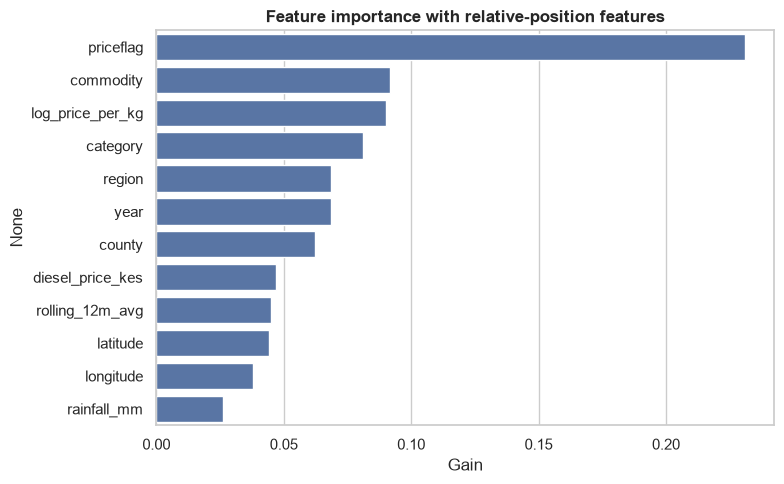

In [34]:
imp_rel = (pd.Series(xgb_rel.feature_importances_, index=Xr_train.columns)
           .sort_values(ascending=False).head(12))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=imp_rel.values, y=imp_rel.index, ax=ax, color="#4C72B0")
ax.set_title("Feature importance with relative-position features")
ax.set_xlabel("Gain")
plt.tight_layout()
plt.show()

## 20. Final model comparison

In [35]:
models_final = {
    'Logistic Regression':           y_pred_lr,
    'Random Forest':                 y_pred_rf,
    'MLP':                           y_pred_mlp,
    'XGBoost (default)':             y_pred_xgb,
    'XGBoost (tuned)':               y_pred_best,
    'XGBoost (target-encoded)':      y_pred_te,
    'XGBoost (no price feature)':    y_pred_nopx,
    'XGBoost (+ relative features)': y_pred_rel,
    'Soft vote (XGB + RF + MLP)':    y_pred_vote,
}

final_table = pd.DataFrame([
    {'Model': name,
     'Accuracy': round(accuracy_score(y_test, p), 3),
     'Balanced Accuracy': round(balanced_accuracy_score(y_test, p), 3),
     'Macro F1': round(f1_score(y_test, p, average='macro'), 3)}
    for name, p in models_final.items()
]).sort_values('Macro F1', ascending=False).reset_index(drop=True)

print(f"Majority-class baseline — accuracy {(y_test == 0).mean():.3f}, "
      f"macro F1 {f1_score(y_test, np.zeros_like(y_test), average='macro'):.3f}")
print()
print(final_table.to_string(index=False))

Majority-class baseline — accuracy 0.661, macro F1 0.265

                        Model  Accuracy  Balanced Accuracy  Macro F1
     XGBoost (target-encoded)     0.717              0.693     0.662
XGBoost (+ relative features)     0.707              0.701     0.660
   Soft vote (XGB + RF + MLP)     0.703              0.697     0.656
              XGBoost (tuned)     0.697              0.698     0.652
            XGBoost (default)     0.680              0.698     0.639
                Random Forest     0.659              0.672     0.617
                          MLP     0.612              0.612     0.567
   XGBoost (no price feature)     0.620              0.594     0.555
          Logistic Regression     0.453              0.564     0.447


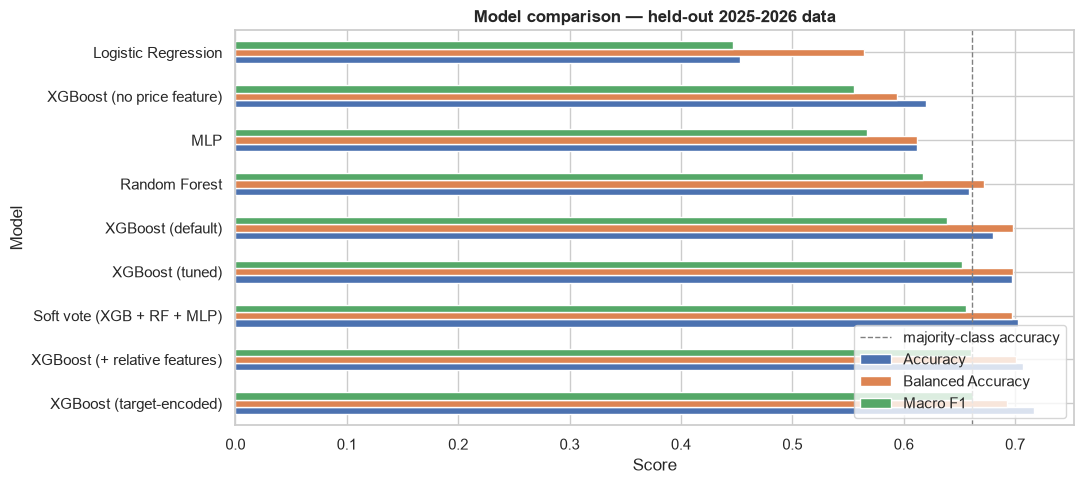

In [36]:
fig, ax = plt.subplots(figsize=(11, 5))
final_table.set_index('Model')[['Accuracy', 'Balanced Accuracy', 'Macro F1']].plot(
    kind='barh', ax=ax)
ax.axvline((y_test == 0).mean(), color='grey', linestyle='--', linewidth=1,
           label='majority-class accuracy')
ax.set_title("Model comparison — held-out 2025-2026 data")
ax.set_xlabel("Score")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 21. Findings

**On the target.** `price_label` is a thresholded version of
`price_vs_regional_avg` — Cheap below 0.9, Expensive above 1.1. That ratio was
excluded from the features. Section 16b tests whether the remaining price
feature reconstructs it.

**On class balance.** The dataset is roughly 67 / 18 / 16 across Average, Cheap
and Expensive. Accuracy alone is therefore misleading — predicting Average for
every row scores 0.66. Macro F1 against a 0.27 baseline is the metric that
reflects performance on the two classes carrying the product value.

Logistic Regression's accuracy of 0.453 sits below the majority baseline. This
is `class_weight='balanced'` trading accuracy for minority-class recall, not
model failure — its balanced accuracy of 0.564 is the fair comparison.

**On validation strategy.** An initial randomized search using shuffled
`StratifiedKFold` returned a best CV macro-F1 of 0.84 against a held-out score
of 0.65. Shuffled folds let the model see patterns from surrounding time
periods. Switching to `TimeSeriesSplit` closed that gap and produced a
conservative estimate, explained in section 16c.

**On ensembling.** Soft voting was tested across XGBoost, Random Forest and the
MLP. Gains are limited when candidate models are correlated, which applies here
since several are tree-based on the same features.

**Limitations.**

- Choices between encodings and feature sets were evaluated on the held-out
  test set, carrying some risk of fitting decisions to that particular window.
- The test period covers 2025–2026 only. Performance in a year with different
  price dynamics is untested.
- The classifier judges price relative to a regional average computed from the
  same dataset. It does not assess affordability, quality or availability.

In [38]:
# 2 — model without priceflag AND without price: the deployable version
cats_clean = [c for c in categorical_cols if c != 'priceflag']
nums_clean = [c for c in numeric_cols if c != 'log_price_per_kg']

X_dep = feature_df[cats_clean + nums_clean].copy()
for col in cats_clean:
    X_dep[col] = encoders[col].transform(X_dep[col].astype(str))
X_dep = X_dep.reset_index(drop=True)

m_dep = xgb.XGBClassifier(**params_clean)
m_dep.fit(X_dep[train_mask.values], y_train, sample_weight=sample_weights)
pred_dep = m_dep.predict(X_dep[~train_mask.values])

print(classification_report(y_test, pred_dep, target_names=label_encoder.classes_))
print(f"Macro F1 — deployable model: {f1_score(y_test, pred_dep, average='macro'):.3f}")

              precision    recall  f1-score   support

     Average       0.80      0.66      0.72      2219
       Cheap       0.40      0.56      0.46       596
   Expensive       0.40      0.51      0.45       542

    accuracy                           0.62      3357
   macro avg       0.53      0.57      0.54      3357
weighted avg       0.66      0.62      0.63      3357

Macro F1 — deployable model: 0.543


The deployed classifier achieves macro F1 of 0.543 against a 0.265 majority baseline, using only market, commodity, location and seasonal features available before a price is observed. Precision on the Cheap class is 0.40 against a 17.6% base rate — sufficient to shortlist candidate markets, not to make a definitive recommendation. A variant including the observed price reaches 0.662, but answers a different question: whether an already-known price is high, rather than which market to visit."

In [40]:
cats_clean = [c for c in categorical_cols if c != 'priceflag']
nums_clean = [c for c in numeric_cols if c != 'log_price_per_kg']

X_dep = feature_df[cats_clean + nums_clean].copy()
for col in cats_clean:
    X_dep[col] = encoders[col].transform(X_dep[col].astype(str))
X_dep = X_dep.reset_index(drop=True)

X_dep_train, X_dep_test = X_dep[train_mask.values], X_dep[~train_mask.values]

params_clean = {k: v for k, v in best_xgb.get_params().items() if k != 'missing'}
xgb_dep = xgb.XGBClassifier(**params_clean)
xgb_dep.fit(X_dep_train, y_train, sample_weight=sample_weights)
y_pred_dep = xgb_dep.predict(X_dep_test)

print(classification_report(y_test, y_pred_dep, target_names=label_encoder.classes_))
print(f"Macro F1: {f1_score(y_test, y_pred_dep, average='macro'):.3f}")
print(f"Features: {list(X_dep_train.columns)}")

              precision    recall  f1-score   support

     Average       0.80      0.66      0.72      2219
       Cheap       0.40      0.56      0.46       596
   Expensive       0.40      0.51      0.45       542

    accuracy                           0.62      3357
   macro avg       0.53      0.57      0.54      3357
weighted avg       0.66      0.62      0.63      3357

Macro F1: 0.543
Features: ['region', 'county', 'market', 'category', 'commodity', 'season', 'month', 'year', 'rainfall_mm', 'diesel_price_kes', 'rolling_12m_avg', 'latitude', 'longitude']


In [41]:
import joblib, json, os
from pathlib import Path

MODELS = Path('../../models')
MODELS.mkdir(parents=True, exist_ok=True)

# ── the deployable model: no price, no priceflag ─────────────────
joblib.dump(xgb_dep, MODELS / 'classifier_xgb.joblib')

# encoders — only for the columns the deployed model actually uses
enc_dep = {col: encoders[col] for col in cats_clean}
joblib.dump(enc_dep, MODELS / 'classifier_encoders.joblib')
joblib.dump(label_encoder, MODELS / 'classifier_label_encoder.joblib')

# ── metadata the API needs to validate and explain a request ─────
meta = {
    'model': 'XGBoost',
    'target': 'price_label',
    'classes': label_encoder.classes_.tolist(),
    'feature_order': list(X_dep_train.columns),
    'categorical_features': cats_clean,
    'numeric_features': nums_clean,
    'excluded_features': {
        'log_price_per_kg': 'numerator of the ratio defining the target; '
                            'unavailable before a price is observed',
        'priceflag': 'data-provenance field; aggregated rows are labelled '
                     'Average 79.6% of the time vs 52.5% for actual readings',
    },
    'train_period': f"{df_reset[train_mask]['year'].min()}-{df_reset[train_mask]['year'].max()}",
    'test_period':  f"{df_reset[~train_mask]['year'].min()}-{df_reset[~train_mask]['year'].max()}",
    'metrics': {
        'accuracy':          round(float(accuracy_score(y_test, y_pred_dep)), 3),
        'balanced_accuracy': round(float(balanced_accuracy_score(y_test, y_pred_dep)), 3),
        'macro_f1':          round(float(f1_score(y_test, y_pred_dep, average='macro')), 3),
        'majority_baseline_accuracy': round(float((y_test == 0).mean()), 3),
        'majority_baseline_macro_f1': round(float(
            f1_score(y_test, np.zeros_like(y_test), average='macro')), 3),
    },
    'per_class': {
        cls: {
            'precision': round(float(v['precision']), 3),
            'recall':    round(float(v['recall']), 3),
            'f1':        round(float(v['f1-score']), 3),
            'support':   int(v['support']),
        }
        for cls, v in classification_report(
            y_test, y_pred_dep, target_names=label_encoder.classes_,
            output_dict=True).items()
        if cls in label_encoder.classes_
    },
    'valid_values': {col: sorted(encoders[col].classes_.tolist()) for col in cats_clean},
}

with open(MODELS / 'classifier_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved to models/')
for p in sorted(MODELS.glob('classifier_*')):
    print(f'  {p.name:34s} {p.stat().st_size/1024:>8.1f} KB')
print()
print('Feature order:', meta['feature_order'])
print('Classes:', meta['classes'])

Saved to models/
  classifier_encoders.joblib              4.9 KB
  classifier_label_encoder.joblib         0.5 KB
  classifier_metadata.json                7.2 KB
  classifier_xgb.joblib               12841.1 KB

Feature order: ['region', 'county', 'market', 'category', 'commodity', 'season', 'month', 'year', 'rainfall_mm', 'diesel_price_kes', 'rolling_12m_avg', 'latitude', 'longitude']
Classes: ['Average', 'Cheap', 'Expensive']
